<a href="https://colab.research.google.com/github/ayslanleal/esc-classification-mlp/blob/main/sbcnn_gtzan_clustering10s.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SB-CNN GTZAN — Treinamento + Clustering (t-SNE / Silhouette)
Pipeline completo: carrega patches → treina SB-CNN → extrai ativações Dense(64) → t-SNE + silhouette

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, confusion_matrix, classification_report

from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPool2D, Activation,
    Flatten, Dense, Dropout, Input
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

RANDOM_STATE = 42
EPOCHS       = 500
BATCH_SIZE   = 32

In [61]:
N_CLASSES = 10


class Model:

    def sbcnn(self, n_classes: int = N_CLASSES) -> Sequential:
        """
        SB-CNN conforme Salamon & Bello (2017).

        Arquitetura:
            l1: Conv(24, 5x5) → MaxPool(4x2) → ReLU
            l2: Conv(48, 5x5) → MaxPool(4x2) → ReLU
            l3: Conv(48, 5x5) → ReLU
            l4: Dropout(0.5)  → Dense(64)    → ReLU
            l5: Dropout(0.5)  → Dense(n_classes) → Softmax

        Input: (128, 128, 1) — log-mel-spectrogram patch de 3s
        """
        model = Sequential([
            Input(shape=(128, 128, 1)),

            # l1
            Conv2D(24, (5, 5), padding='same'),
            MaxPool2D(pool_size=(4, 2)),
            Activation('relu'),

            # l2
            Conv2D(48, (5, 5), padding='same'),
            MaxPool2D(pool_size=(4, 2)),
            Activation('relu'),

            # l3 (sem pooling)
            Conv2D(48, (5, 5), padding='valid'),
            Activation('relu'),

            # flatten antes das densas
            Flatten(),

            # l4 — dropout na entrada da camada densa
            Dropout(0.5),
            Dense(64, kernel_regularizer=l2(0.001)),
            Activation('relu'),

            # l5 — dropout na entrada da camada de saída
            Dropout(0.5),
            Dense(n_classes, kernel_regularizer=l2(0.001)),
            Activation('softmax'),
        ])

        model.compile(
            optimizer=Adam(learning_rate=1e-4),
            loss='sparse_categorical_crossentropy',  # labels como inteiros
            metrics=['accuracy'],
        )

        return model

## 1. Carrega dataset

In [62]:
df = pd.read_pickle('./gtzan10s.pkl')
print('Shape:', df.shape)
print(df['label'].value_counts())

Shape: (2997, 4)
label
blues        300
classical    300
country      300
disco        300
hiphop       300
metal        300
reggae       300
pop          300
rock         300
jazz         297
Name: count, dtype: int64


## 2. Prepara features e labels

In [63]:
le = LabelEncoder()
y  = le.fit_transform(df['label'].values)
X  = np.stack(df['features'].values)[..., np.newaxis]  # (N, 128, 128, 1)

print('Classes:', le.classes_)
print('X shape:', X.shape)
print('y shape:', y.shape)

Classes: ['blues' 'classical' 'country' 'disco' 'hiphop' 'jazz' 'metal' 'pop'
 'reggae' 'rock']
X shape: (2997, 128, 128, 1)
y shape: (2997,)


## 3. Divisão treino / teste — 80/20 estratificado por áudio original

O split é feito sobre os **arquivos originais** (evita data leakage entre patches do mesmo áudio).

In [64]:
# identificar arquivos únicos e seus labels
df_files = df[['path', 'label']].drop_duplicates()

train_paths, test_paths = train_test_split(
    df_files['path'].values,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=df_files['label'].values,
)

train_mask = df['path'].isin(train_paths)
test_mask  = df['path'].isin(test_paths)

X_train, y_train = X[train_mask], y[train_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

print(f'Treino : {X_train.shape[0]} patches ({len(train_paths)} áudios)')
print(f'Teste  : {X_test.shape[0]} patches ({len(test_paths)} áudios)')

Treino : 2397 patches (799 áudios)
Teste  : 600 patches (200 áudios)


## 4. Treina SB-CNN

In [65]:
model = Model().sbcnn(n_classes=len(le.classes_))
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 128, 128, 24)   │           624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 32, 64, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_20 (Activation)      │ (None, 32, 64, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 32, 64, 48)     │        28,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 8, 32, 48)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_21 (Activation)      │ (None, 8, 32, 48)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 4, 28, 48)      │        57,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_22 (Activation)      │ (None, 4, 28, 48)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 5376)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 5376)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │       344,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_23 (Activation)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_24 (Activation)      │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 431,898 (1.65 MB)

 Trainable params: 431,898 (1.65 MB)

 Non-trainable params: 0 (0.00 B)

In [66]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint(
    'save_models_1/sbcnn_gtzan.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1,
)
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=20,
    restore_best_weights=True,
)

history = model.fit(
    X_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=500,
    validation_data=(X_test, y_test),
    callbacks=[checkpoint, early_stop],
)

Epoch 1/500
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.0968 - loss: 5.9776
Epoch 1: val_accuracy improved from None to 0.11667, saving model to save_models_1/sbcnn_gtzan.keras

Epoch 1: finished saving model to save_models_1/sbcnn_gtzan.keras
75/75 ━━━━━━━━━━━━━━━━━━━━ 10s 78ms/step - accuracy: 0.1122 - loss: 3.5645 - val_accuracy: 0.1167 - val_loss: 2.4067
Epoch 2/500
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.1308 - loss: 2.4147
Epoch 2: val_accuracy improved from 0.11667 to 0.17500, saving model to save_models_1/sbcnn_gtzan.keras

Epoch 2: finished saving model to save_models_1/sbcnn_gtzan.keras
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.1460 - loss: 2.3908 - val_accuracy: 0.1750 - val_loss: 2.3572
Epoch 3/500
73/75 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1695 - loss: 2.3491
Epoch 3: val_accuracy improved from 0.17500 to 0.27833, saving model to save_models_1/sbcnn_gtzan.keras

Epoch 3: finished saving model to save_models_1/sbcnn_gtzan.keras

## 5. Curvas de acurácia e loss

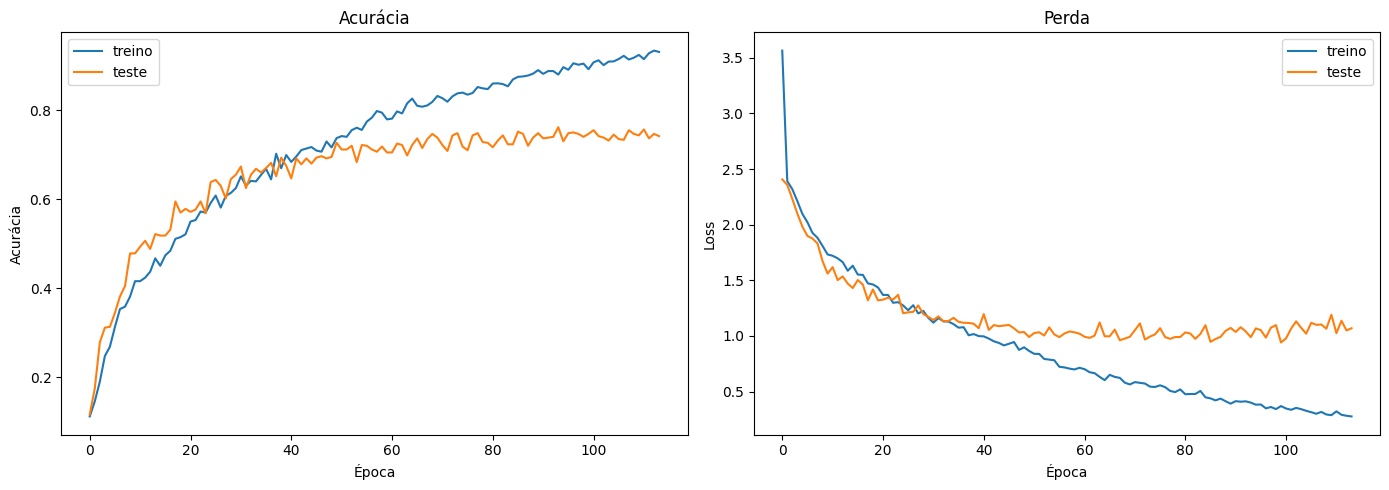

In [67]:
import os

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],     label='treino')
axes[0].plot(history.history['val_accuracy'], label='teste')
axes[0].set_title('Acurácia')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Acurácia')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='treino')
axes[1].plot(history.history['val_loss'], label='teste')
axes[1].set_title('Perda')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/sbcnn_gtzan_curvas.png', dpi=150)
plt.show()

## 6. Avaliação — classification report e matriz de confusão

In [68]:
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f'Loss teste : {loss:.4f}')
print(f'Acurácia   : {acc:.4f}')

y_pred = model.predict(X_test).argmax(axis=1)
print('\n', classification_report(y_test, y_pred, target_names=le.classes_))

Loss teste : 0.9890
Acurácia   : 0.7617
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step

               precision    recall  f1-score   support

       blues       0.83      0.83      0.83        60
   classical       0.88      0.97      0.92        60
     country       0.62      0.77      0.69        60
       disco       0.79      0.45      0.57        60
      hiphop       0.76      0.88      0.82        60
        jazz       0.79      0.87      0.83        60
       metal       0.91      0.85      0.88        60
         pop       0.60      0.83      0.70        60
      reggae       0.81      0.65      0.72        60
        rock       0.72      0.52      0.60        60

    accuracy                           0.76       600
   macro avg       0.77      0.76      0.76       600
weighted avg       0.77      0.76      0.76       600



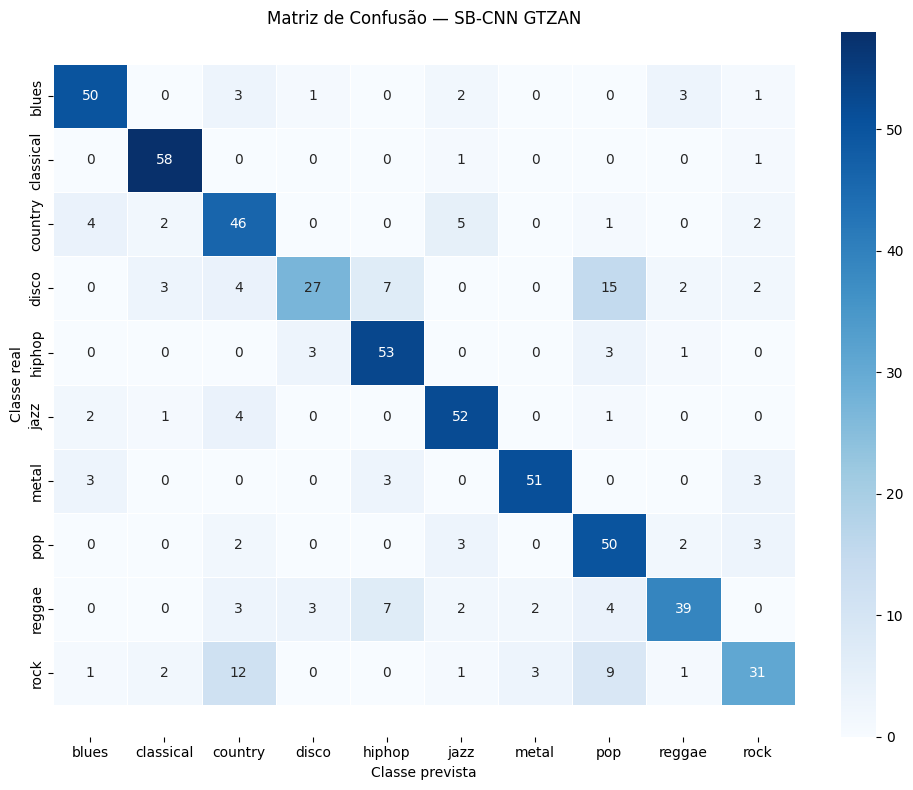

In [69]:
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)

plt.figure(figsize=(10, 8))
ax = sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', linewidths=0.5)
bottom, top = ax.get_ylim()
ax.set_ylim(bottom + 0.5, top - 0.5)
plt.title('Matriz de Confusão — SB-CNN GTZAN')
plt.xlabel('Classe prevista')
plt.ylabel('Classe real')
plt.tight_layout()
plt.savefig('figures/sbcnn_gtzan_matriz.png', dpi=150)
plt.show()

## 7. Extração de ativações — penúltima camada Dense(64)

In [70]:
# Encontra o índice da camada Dense(64) e pega a Activation('relu') seguinte
dense64_idx = next(
    i for i, layer in enumerate(model.layers)
    if hasattr(layer, 'units') and layer.units == 64
)
relu64_idx = dense64_idx + 1  # Activation('relu') logo após Dense(64)

print(f"Dense(64) → layer[{dense64_idx}]: {model.layers[dense64_idx].name}")
print(f"ReLU      → layer[{relu64_idx}]: {model.layers[relu64_idx].name}")

# modelo auxiliar que retorna as ativações do ReLU após Dense(64)
_ = model(tf.zeros((1, 128, 128, 1)))  # garante que o modelo foi chamado ao menos uma vez

hidden_model = tf.keras.Model(
    inputs=model.inputs,
    outputs=model.layers[relu64_idx].output,
)

train_hidden = hidden_model.predict(X_train, verbose=0)
test_hidden  = hidden_model.predict(X_test,  verbose=0)

print('Ativações treino:', train_hidden.shape)
print('Ativações teste :', test_hidden.shape)

Dense(64) → layer[10]: dense_8
ReLU      → layer[11]: activation_23
Ativações treino: (2397, 64)
Ativações teste : (600, 64)


## 8. t-SNE — visualização do espaço latente

In [71]:
def plot_tsne(features, labels, le, title, save_path=None):
    tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=40, n_iter=1000)
    proj = tsne.fit_transform(features)

    plt.figure(figsize=(12, 8))
    palette = sns.color_palette('tab10', len(le.classes_))
    for i, cls in enumerate(le.classes_):
        mask = labels == i
        plt.scatter(proj[mask, 0], proj[mask, 1], label=cls, s=15, alpha=0.7, color=palette[i])

    plt.title(title)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()
    return proj

Rodando t-SNE no conjunto de treino...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


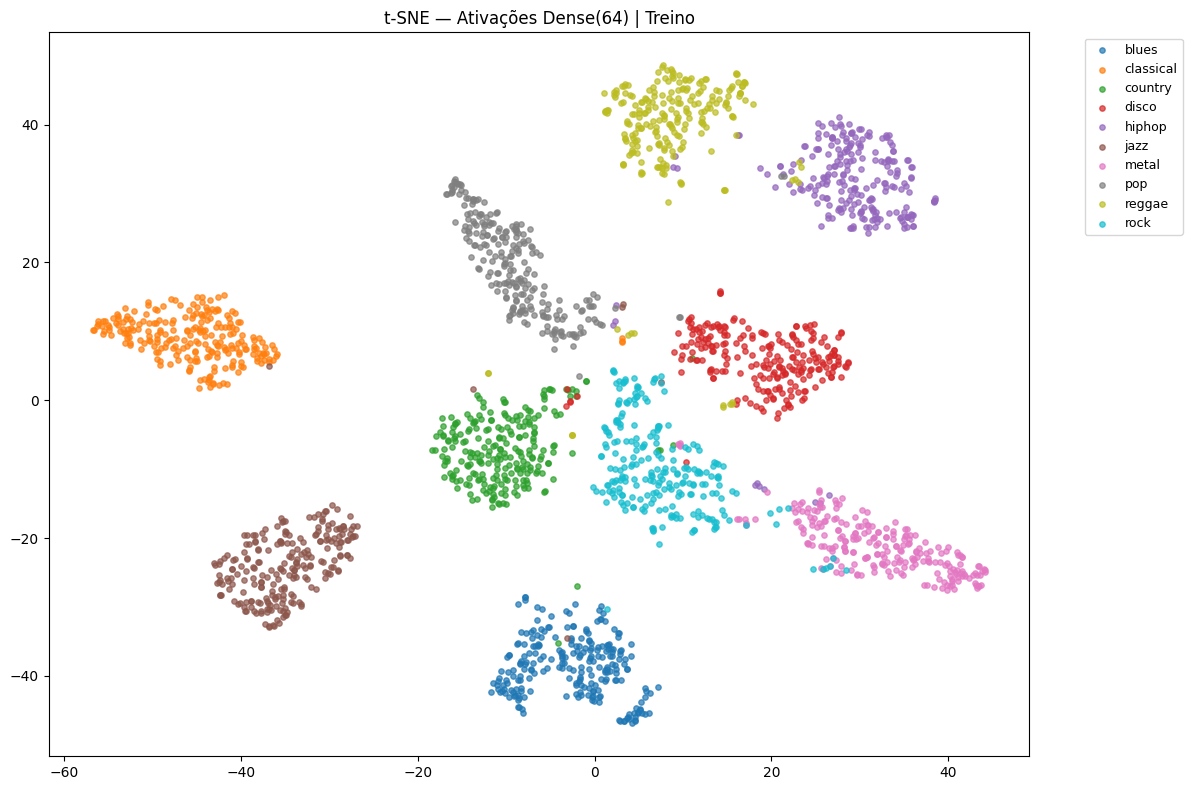

In [72]:
print('Rodando t-SNE no conjunto de treino...')
proj_train = plot_tsne(
    train_hidden, y_train, le,
    title='t-SNE — Ativações Dense(64) | Treino',
    save_path='figures/sbcnn_gtzan_tsne_treino.png',
)

Rodando t-SNE no conjunto de teste...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


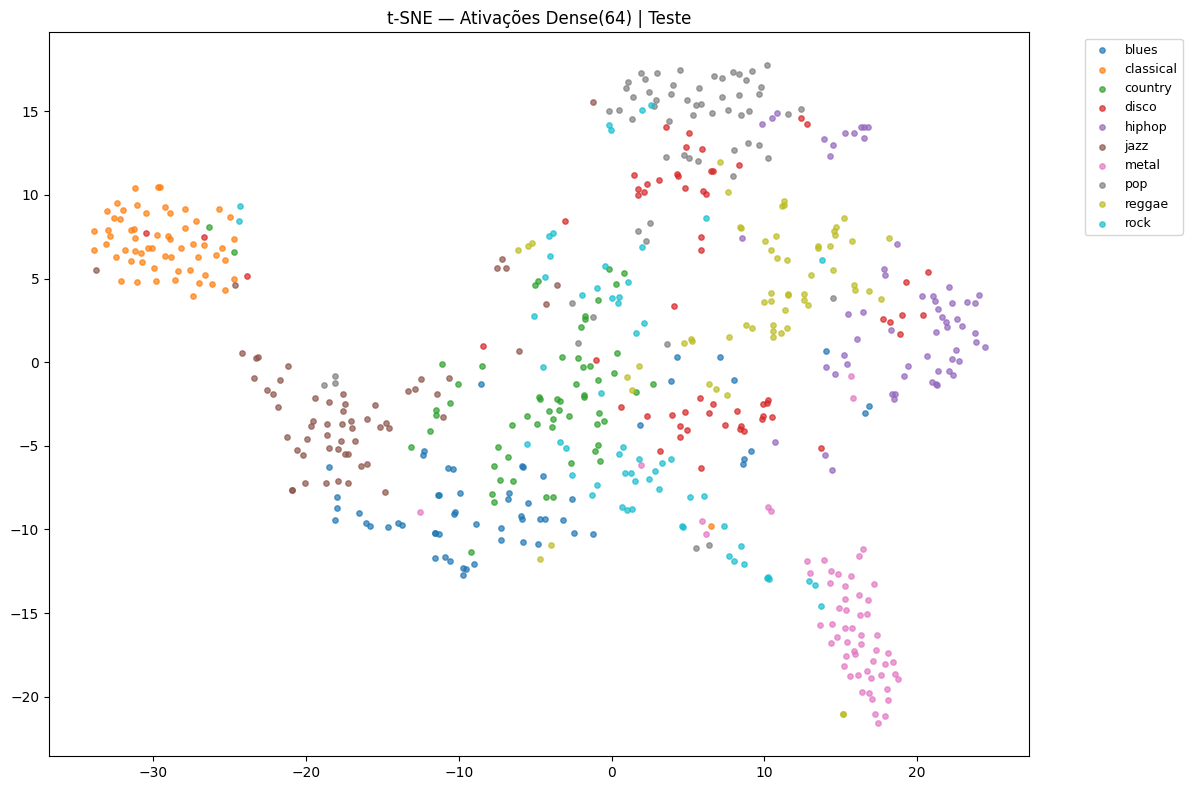

In [73]:
print('Rodando t-SNE no conjunto de teste...')
proj_test = plot_tsne(
    test_hidden, y_test, le,
    title='t-SNE — Ativações Dense(64) | Teste',
    save_path='figures/sbcnn_gtzan_tsne_teste.png',
)

## 9. Silhouette Score

In [74]:
sil_train = silhouette_score(proj_train, y_train)
sil_test  = silhouette_score(proj_test,  y_test)

print(f'Silhouette Score — Treino : {sil_train:.4f}')
print(f'Silhouette Score — Teste  : {sil_test:.4f}')
print()
print('Interpretação:')
print('  ~1.0 → classes bem separadas')
print('  ~0.0 → classes sobrepostas')
print('  < 0  → amostras mais próximas de outra classe')

Silhouette Score — Treino : 0.5894
Silhouette Score — Teste  : 0.1785

Interpretação:
  ~1.0 → classes bem separadas
  ~0.0 → classes sobrepostas
  < 0  → amostras mais próximas de outra classe


## 10. Silhouette por classe

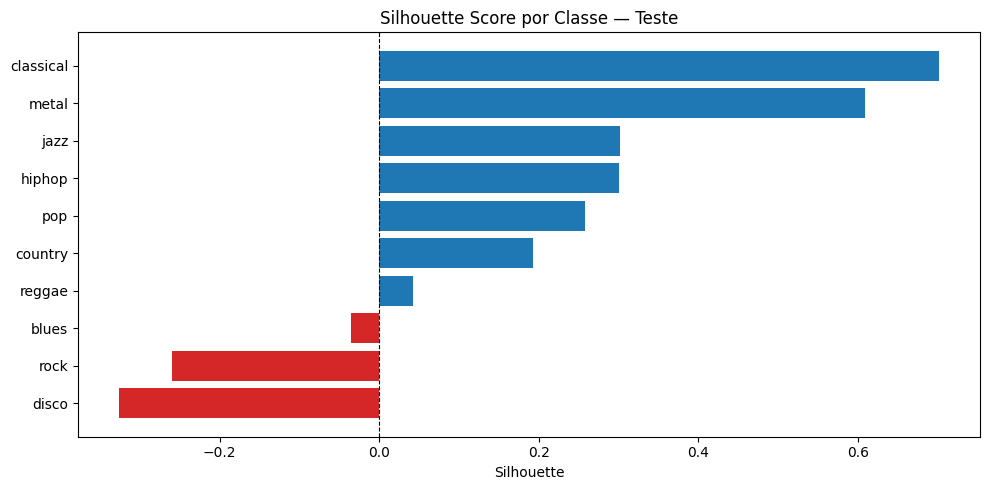

   classe  silhouette
    disco   -0.325982
     rock   -0.259721
    blues   -0.035777
   reggae    0.042505
  country    0.192464
      pop    0.258510
   hiphop    0.300389
     jazz    0.301572
    metal    0.609186
classical    0.701907


In [75]:
from sklearn.metrics import silhouette_samples

sil_samples = silhouette_samples(proj_test, y_test)
sil_per_class = {
    cls: sil_samples[y_test == i].mean()
    for i, cls in enumerate(le.classes_)
}

sil_df = pd.DataFrame(sil_per_class.items(), columns=['classe', 'silhouette']).sort_values('silhouette')

plt.figure(figsize=(10, 5))
colors = ['#d62728' if v < 0 else '#1f77b4' for v in sil_df['silhouette']]
plt.barh(sil_df['classe'], sil_df['silhouette'], color=colors)
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Silhouette Score por Classe — Teste')
plt.xlabel('Silhouette')
plt.tight_layout()
plt.savefig('figures/sbcnn_gtzan_silhouette_classes.png', dpi=150)
plt.show()

print(sil_df.to_string(index=False))